In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import shutil
import re

# Ahora importa el módulo
from RRAM.Representate import config_ax

def setup_plt(plt, latex=True, scaling=1):
    plt.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": latex,
            "font.family": "mathpazo",
            "text.latex.preamble": "\n".join(
                [
                    r"\usepackage[utf8]{inputenc}",
                    r"\usepackage[T1]{fontenc}",
                    r"\usepackage{siunitx}",
                    r"\usepackage{physics}",
                ]
            ),
        }
    )

    SMALL_SIZE = 8 * scaling
    MEDIUM_SIZE = 10 * scaling
    BIGGER_SIZE = 11 * scaling

    plt.rc("font", size=SMALL_SIZE)
    plt.rc("axes", titlesize=SMALL_SIZE)
    plt.rc("axes", labelsize=MEDIUM_SIZE)
    plt.rc("xtick", labelsize=SMALL_SIZE)
    plt.rc("ytick", labelsize=SMALL_SIZE)
    plt.rc("legend", fontsize=SMALL_SIZE)
    plt.rc("figure", titlesize=BIGGER_SIZE)
    plt.rc("axes", titlesize=BIGGER_SIZE)

In [2]:
# Rutas de los archivos
ruta_datos = (Path.cwd() / "Datos_Experimentales" / "Medidas_Experimentales_RRAM")
ruta_figuras = Path.cwd() / "Datos_Experimentales" / "V_Set"


if ruta_figuras.exists():
    shutil.rmtree(ruta_figuras)
    ruta_figuras.mkdir(exist_ok=True)
else:
    ruta_figuras.mkdir(exist_ok=True)
    
# Listar todos los archivos
archivos = []
for archivo in ruta_datos.glob("Cycle_p_*.txt"):
    # Buscar el número dentro del nombre (después de "Cycle_p_")
    match = re.fullmatch(r"Cycle_p_(\d{3,4})\.txt", archivo.name)
    if match:
        numero = int(match.group(1))  # convertir a entero
        if 800 <= numero <= 1200:  # aplicar filtro de rango
            archivos.append(archivo)

print(f"Archivos encontrados: {len(archivos)}")
print(archivos)

Archivos encontrados: 401
[WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1000.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1001.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1002.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1003.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1004.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1005.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_1006.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RR

In [3]:
def plot_iv_and_derivative(voltaje, intensidad, dI_dV, top_indices, ruta_figuras):
    """
    Plots the I-V curve and its derivative, highlighting specific points with the highest derivative values.
    Parameters:
    -----------
    V_set : array-like
        Array of voltage values (x-axis data).
    I_set : array-like
        Array of current values corresponding to the voltage values (y-axis data for the I-V curve).
    dI_dV : array-like
        Array of derivative values (y-axis data for the derivative plot).
    top_indices : list of int
        Indices of the points with the highest derivative values to be highlighted on the plots.
    ruta_figuras : str
        File path where the generated figure will be saved.
    Returns:
    --------
    None
        The function saves the generated plot as an image file at the specified location.
    Notes:
    ------
    - The function creates a figure with two subplots:
        1. The I-V curve with logarithmic scaling on the y-axis.
        2. The derivative of the I-V curve.
    - Points with the highest derivative values are highlighted in red on both subplots.
    - The figure is saved as an image file in the specified path with a resolution of 300 dpi.
    """
    
    # Crear una figura con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # === Configuración de estilo LaTeX y plot ===
    setup_plt(plt, latex=True, scaling=2)

    config_ax(ax1)
    config_ax(ax2)

    # En el primer subplot, graficar la curva I-V
    ax1.plot(voltaje, intensidad, "b-", linewidth=2)
    ax1.set_xlabel(r"Voltaje (\si{\volt})")
    ax1.set_ylabel(r"Corriente (\si{\ampere})")
    ax1.set_title("Curva I-V")
    ax1.set_yscale("log")
    ax1.grid(True)

    # Solo marcar los puntos con mayor derivada en el primer subplot
    for idx in top_indices:
        ax1.plot(voltaje[idx], intensidad[idx], "o", markersize=6, color="red")
        ax1.annotate(
            f"{voltaje[idx]:.2f} V",
            (voltaje[idx], intensidad[idx]),
            textcoords="offset points",
            xytext=(-35, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )

    # En el segundo subplot, graficar la derivada de la corriente respecto al voltaje
    ax2.plot(voltaje, dI_dV, "-", linewidth=2, color = "blue")
    ax2.set_xlabel(r"Voltaje (\si{\volt})")
    ax2.set_ylabel(r"$\dv{I}{V}$ (\si{\ampere/\volt})")
    ax2.set_title("Derivada de la curva I-V")
    ax2.grid(True)

    # Solo marcar los puntos con mayor derivada en el segundo subplot
    for idx in top_indices:
        ax2.plot(voltaje[idx], dI_dV[idx], "o", markersize=6, color="red")
        ax2.annotate(
            f"{voltaje[idx]:.2f} V",
            (voltaje[idx], dI_dV[idx]),
            textcoords="offset points",
            xytext=(-25, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )
        
    fig.savefig(str(ruta_figuras) + ".pdf", dpi=300, bbox_inches="tight")  # type: ignore
    plt.close(fig)
    
    # Crear figura combinada con eje secundario
    fig_combinada, ax_comb_1 = plt.subplots(figsize=(12, 9))
    
    setup_plt(plt, latex=True, scaling=2)
    config_ax(ax_comb_1)
    
    # ---- Eje izquierdo (Corriente) ----
    ax_comb_1.semilogy(voltaje, intensidad, "o-", color="blue", label=r"Corriente (\si{\ampere})")
    ax_comb_1.set_xlabel(r"Voltaje (\si{\volt})")
    ax_comb_1.set_ylabel(r"Corriente (\si{\ampere})", color="blue")
    ax_comb_1.tick_params(axis="y", labelcolor="blue")

    # Solo marcar los puntos con mayor derivada en el primer subplot
    for idx in top_indices:
        ax_comb_1.plot(voltaje[idx], intensidad[idx], "o", markersize=6, color="red")
        ax_comb_1.annotate(
            f"{voltaje[idx]:.2f} V",
            (voltaje[idx], intensidad[idx]),
            textcoords="offset points",
            xytext=(-35, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )
    
    # ---- Eje derecho (Derivada) ----
    ax_comb_2 = ax_comb_1.twinx()  # Crear un eje Y secundario
    config_ax(ax2)
    ax_comb_2.plot(
        voltaje, dI_dV, "o-", color="orange", label=r"$\dv{I}{V}$ (\si{\ampere/\volt})"
    )
    ax_comb_2.set_ylabel(r"$\dv{I}{V}$ (\si{\ampere/\volt})", color="orange")
    ax_comb_2.tick_params(axis="y", labelcolor="orange")

    # Solo marcar los puntos con mayor derivada en el segundo subplot
    for idx in top_indices:
        ax_comb_2.plot(voltaje[idx], dI_dV[idx], "o", markersize=6, color="green")
        ax_comb_2.annotate(
            f"{voltaje[idx]:.2f} V",
            (voltaje[idx], dI_dV[idx]),
            textcoords="offset points",
            xytext=(-25, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )
    
    # Leyendas combinadas
    lines1, labels1 = ax_comb_1.get_legend_handles_labels()
    lines2, labels2 = ax_comb_2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    plt.title("I-V y su Derivada")
    
    fig_combinada.savefig(
        str(ruta_figuras) + "_combinado.pdf", dpi=300, bbox_inches="tight"
    )  # type: ignore
    plt.close(fig_combinada)

In [4]:
def obtener_V_set(ruta_datos, num_valores_maximos=3):
    """
    Analiza un archivo de datos experimentales para calcular la derivada de la corriente 
    con respecto al voltaje, identifica los valores máximos de la derivada y genera una 
    gráfica de los datos.
    Args:
        ruta_datos (Path): Ruta al archivo que contiene los datos experimentales. 
            El archivo debe existir y contener tres columnas: "Voltaje", "Corriente" y "tiempo".
        num_valores_maximos (int, opcional): Número de valores máximos de la derivada a extraer. 
            Por defecto es 5.
    Returns:
        dict: Un diccionario con las siguientes claves:
            - "top_derivadas" (np.ndarray): Los valores máximos de la derivada numérica.
            - "top_voltajes" (np.ndarray): Los voltajes correspondientes a los valores máximos 
              de la derivada.
    Raises:
        FileNotFoundError: Si el archivo especificado en `ruta_datos` no existe.
    Notas:
        - La función filtra los datos para considerar solo las primeras 111 filas del archivo.
        - Genera una gráfica que muestra la curva IV y la derivada, y la guarda en una 
          subcarpeta "Datos_Experimentales/V_Set" con un nombre basado en el archivo de entrada.
    """
    # Verificar que el archivo existe
    if not ruta_datos.exists():
        raise FileNotFoundError(
            f"El archivo {ruta_datos} no existe. Verificar la ruta."
        )

    # Cargar datos experimentales
    data_set = np.loadtxt(ruta_datos)

    # Crear el DataFrame
    df_set = pd.DataFrame(data_set, columns=["Voltaje", "Corriente", "tiempo"])
    df_set = df_set.iloc[0:110]  # Seleccionar solo las primeras 111 filas
    
    # Combinación de ambos filtros
    # Primero, resetea los índices después del filtrado
    df_set_filtrado = df_set.loc[(df_set['Voltaje'] >= 0.3) & (df_set['Voltaje'] <= 0.8)].reset_index(drop=True)

    # Calcular la derivada numérica de la corriente con respecto al voltaje
    dI_dV = np.gradient(np.log10(df_set_filtrado["Corriente"]), df_set_filtrado['Voltaje'])

    # Extraer los índices de los valores máximos
    indices_maximos = np.argsort(dI_dV)[-num_valores_maximos:]

    # Extraer los valores máximos y sus voltajes correspondientes
    top_derivadas = dI_dV[indices_maximos]
    top_voltages = df_set_filtrado["Voltaje"].values[indices_maximos]
    
    # V_set = df_set_filtrado["Voltaje"]
    # I_set = df_set_filtrado["Corriente"]
    
    # ruta_figuras = (
    #     Path.cwd()
    #     / "Datos_Experimentales"
    #     / "V_Set"
    #     / f"{ruta_datos.stem}"
    # )
    
    # plot_iv_and_derivative(V_set, I_set, dI_dV, indices_maximos, ruta_figuras)
    
    # Retornar resultados en un diccionario
    return {
        "top_derivadas": top_derivadas,
        "top_voltajes": top_voltages,
    }

In [5]:
for datos in archivos:   
    resultados = obtener_V_set(datos, num_valores_maximos=3)
    
    # Encuentra el índice del voltaje más bajo
    idx_min_voltaje = np.argmin(resultados["top_voltajes"])
    voltaje_min = resultados["top_voltajes"][idx_min_voltaje]
    derivada_min = resultados["top_derivadas"][idx_min_voltaje]

    # Guardo los resultados en un único archivo de texto
    with open(ruta_figuras / "V_set_experimental.txt", "a") as f:
        f.write(f"{datos.stem}\t{voltaje_min:.4f}\t{derivada_min:.4e}\n")


In [6]:
results_path = ruta_figuras / "V_set_experimental.txt"

resultados_txt = np.genfromtxt(
    results_path, dtype=[('Archivo', 'U50'),    # String Unicode de máx 50 caracteres
                                   ('V_set', 'f8'),        # Float de 64 bits
                                   ('Derivada', 'f8')], encoding="utf-8", names=["Archivo", "V_set", "Derivada"]
)

# Crear un DataFrame para una mejor visualización
df_resultados = pd.DataFrame(resultados_txt)
df_resultados = df_resultados.rename(
    columns={"V_set": "V_set (V)", "Derivada": "Derivada (A/V)"}
)

df_resultados["Numero"] = (
    df_resultados["Archivo"].str.extract(r"Cycle_p_(\d+)", expand=False).astype(int)
)

In [7]:
ruta_archivos_simulacion = (Path.cwd() / "logs")

# Listar todos los archivos
resultados = []

for archivo in ruta_archivos_simulacion.glob("log_simulacion_*.log"):
    with open(archivo, "r", encoding="utf-8") as f:
        contenido = f.read()

    # Buscar el número después de "voltaje:"
    match = re.search(r"voltaje:\s*([0-9]*\.?[0-9]+)", contenido)
    if match:
        valor = float(match.group(1))
        valor_redondeado = round(valor, 4)
        print(f"Archivo: {archivo.name}, Voltaje: {valor_redondeado}")
        # Guardo los resultados en un único archivo de texto
        with open(ruta_figuras / "V_set_simulacion.txt", "a") as f:
            f.write(f"{archivo.name}\t{valor_redondeado}\n")
            
results_path = ruta_figuras / "V_set_simulacion.txt"

resultados_txt = np.genfromtxt(
    results_path,
    dtype=[
        ("Archivo", "U50"),  # String Unicode de máx 50 caracteres
        ("V_set", "f8"),  # Float de 64 bits
    ],
    encoding="utf-8",
    names=["Archivo", "V_set"],
)

# Crear un DataFrame para una mejor visualización
df_resultados_sim = pd.DataFrame(resultados_txt)
df_resultados_sim = df_resultados_sim.rename(
    columns={"V_set": "V_set (V)", "Derivada": "Derivada (A/V)"}
)

df_resultados_sim["Numero"] = (
    df_resultados_sim["Archivo"]
    .str.extract(r"log_simulacion_(\d+)", expand=False)
    .astype(int)
)

print(df_resultados_sim)



Archivo: log_simulacion_1.log, Voltaje: 0.4333
Archivo: log_simulacion_10.log, Voltaje: 0.4087
Archivo: log_simulacion_100.log, Voltaje: 0.4486
Archivo: log_simulacion_101.log, Voltaje: 0.4316
Archivo: log_simulacion_102.log, Voltaje: 0.4661
Archivo: log_simulacion_103.log, Voltaje: 0.4704
Archivo: log_simulacion_104.log, Voltaje: 0.4866
Archivo: log_simulacion_105.log, Voltaje: 0.505
Archivo: log_simulacion_106.log, Voltaje: 0.4371
Archivo: log_simulacion_107.log, Voltaje: 0.4453
Archivo: log_simulacion_108.log, Voltaje: 0.4434
Archivo: log_simulacion_109.log, Voltaje: 0.4214
Archivo: log_simulacion_11.log, Voltaje: 0.4294
Archivo: log_simulacion_110.log, Voltaje: 0.4917
Archivo: log_simulacion_111.log, Voltaje: 0.4934
Archivo: log_simulacion_112.log, Voltaje: 0.4586
Archivo: log_simulacion_113.log, Voltaje: 0.4497
Archivo: log_simulacion_114.log, Voltaje: 0.4626
Archivo: log_simulacion_115.log, Voltaje: 0.474
Archivo: log_simulacion_116.log, Voltaje: 0.4621
Archivo: log_simulacion_11

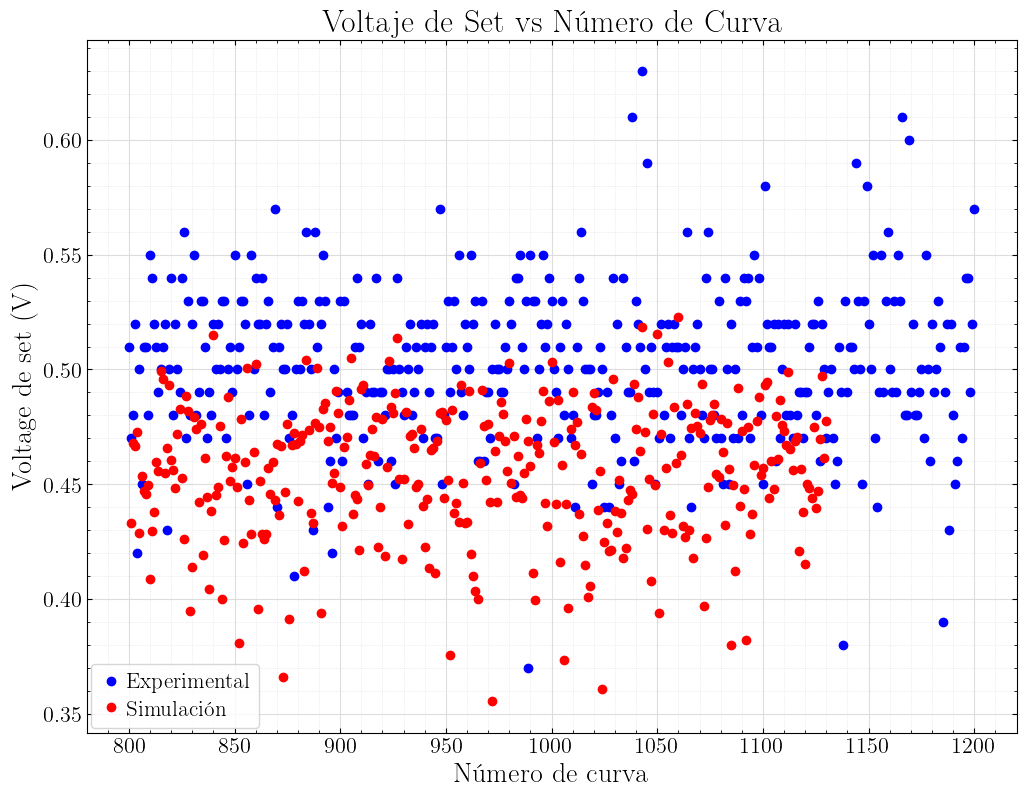

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
config_ax(ax)

ax.plot(df_resultados["Numero"], df_resultados["V_set (V)"], "o", color="blue", label="Experimental")
ax.plot(df_resultados_sim["Numero"]+800, df_resultados_sim["V_set (V)"], "o", color="red", label="Simulación")
ax.set_xlabel(r"Número de curva")
ax.set_ylabel(r"Voltage de set (\si{\volt})")
ax.legend(
    labelspacing=0.3,
    handletextpad=0.2,
    handlelength=1.0,
    borderaxespad=0.2,
    loc="lower left",
)
ax.set_title("Voltaje de Set vs Número de Curva")

# === Configuración de estilo LaTeX y plot ===
setup_plt(plt, latex=True, scaling=2)
